# Pipeline de Machine Learning - Supervisé

L'objectif de ce notebook est de créer un pipeline d'apprentissage automatique automatisé, optimisé pour la précision plutôt que pour le temps d'exécution. Chaque décision de nettoyage de données sera justifiée, et nous utiliserons une recherche exhaustive (`GridSearchCV`) pour trouver le meilleur algorithme.

In [3]:
%pip install seaborn scikit-learn

In [23]:
# =========================================================
# 0. CONFIGURATION GLOBALE ET IMPORTS
# =========================================================

import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

# 1. Imports prioritaires (indispensables pour la config)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Configuration (Maintenant 'np' est défini)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# 3. Prétraitement et Modèles
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

# 4. Évaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, RocCurveDisplay
)

# Importation

✅ Dataset chargé avec succès depuis 'Titanic-Dataset.csv'.
📊 Dimensions du dataset : 891 lignes × 12 colonnes

--- Aperçu des 5 premières lignes ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



--- Résumé technique (types, valeurs non nulles) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 66.2+ KB

--- Statistiques descriptives (numériques) ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- Statistiques pour les colonnes catégorielles ---


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,B96 B98,S
freq,1,577,7,4,644


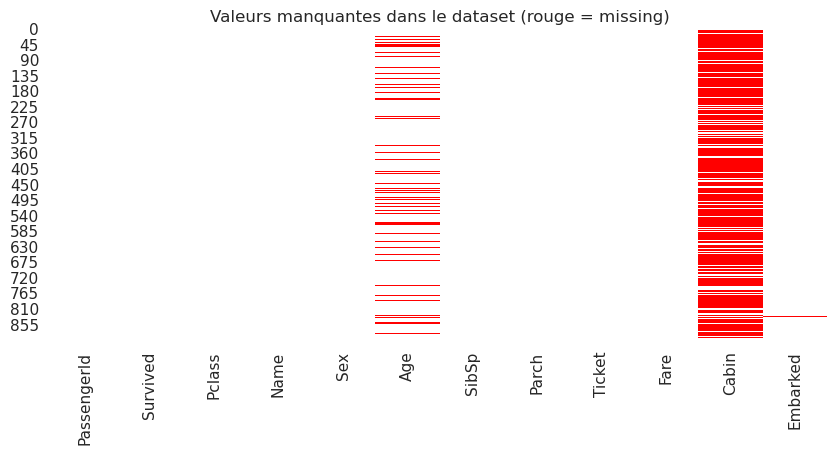

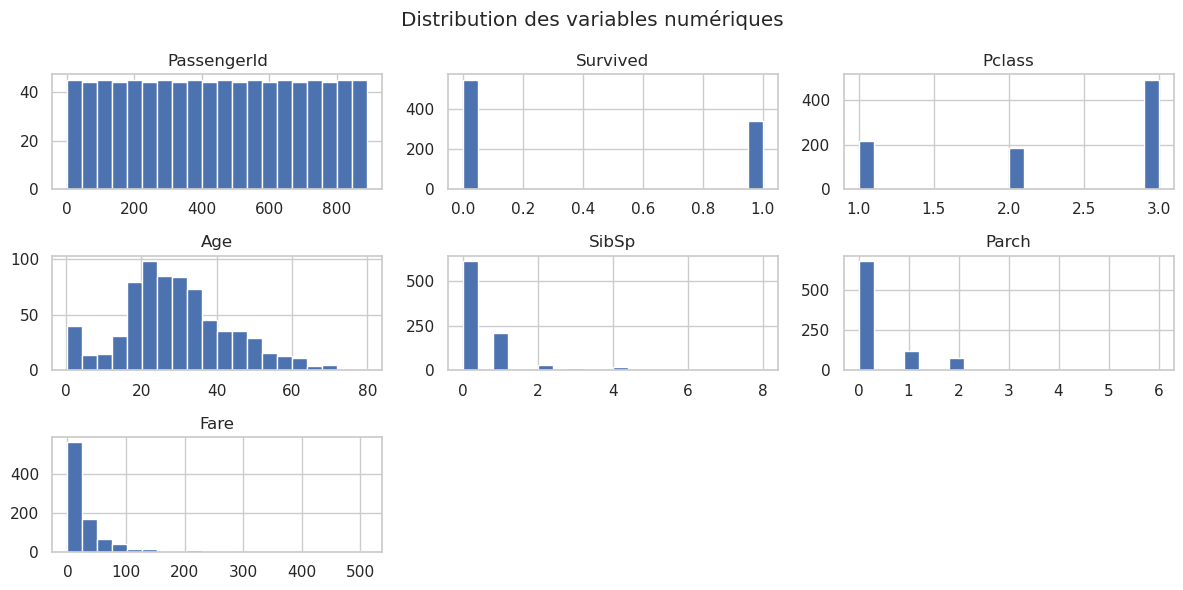

In [26]:
# =========================================================
# 1. PARAMÈTRES ET CHARGEMENT DES DONNÉES
# =========================================================

# --- Paramètres ---
CHEMIN_FICHIER = 'Titanic-Dataset.csv'  # Constante en majuscules pour les paramètres globaux

def charger_donnees(chemin: str) -> pd.DataFrame:
    """Charge un dataset depuis un fichier CSV et retourne un DataFrame."""
    try:
        df = pd.read_csv(chemin)
        print(f"✅ Dataset chargé avec succès depuis '{chemin}'.")
        return df
    except FileNotFoundError:
        print(f"❌ Erreur : Fichier '{chemin}' introuvable.")
        return None
    except Exception as e:
        print(f"❌ Erreur inattendue : {e}")
        return None

# Chargement des données
df = charger_donnees(CHEMIN_FICHIER)

# =========================================================
# 2. EXPLORATION INITIALE (EDA)
# =========================================================

def exploration_initiale(df: pd.DataFrame) -> None:
    """Affiche un résumé complet du dataset pour l'EDA initiale."""
    if df is None:
        return

    # --- Dimensions ---
    print(f"📊 Dimensions du dataset : {df.shape[0]} lignes × {df.shape[1]} colonnes")

    # --- Aperçu des données ---
    print("\n--- Aperçu des 5 premières lignes ---")
    display(df.head())

    # --- Résumé technique ---
    print("\n--- Résumé technique (types, valeurs non nulles) ---")
    df.info()

    # --- Statistiques descriptives ---
    print("\n--- Statistiques descriptives (numériques) ---")
    display(df.describe(include=[np.number]))

    # --- Statistiques pour les colonnes catégorielles ---
    print("\n--- Statistiques pour les colonnes catégorielles ---")
    display(df.describe(include=['object', 'category']))

    # --- Visualisation : Valeurs manquantes ---
    plt.figure(figsize=(10, 4))
    sns.heatmap(df.isnull(), cbar=False, cmap=['white', 'red'])
    plt.title("Valeurs manquantes dans le dataset (rouge = missing)")
    plt.show()

    # --- Visualisation : Distribution des variables numériques ---
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        df[numeric_cols].hist(figsize=(12, 6), bins=20)
        plt.suptitle("Distribution des variables numériques")
        plt.tight_layout()
        plt.show()

# Exécution de l'exploration initiale
exploration_initiale(df)

# **Prétraitement**
*Objectif : Nettoyer, transformer et préparer les données pour la modélisation.*

---

## **1. Détection des Colonnes Inutiles**
- **Critère** : Suppression des colonnes avec une **cardinalité > 50%** (ex : `PassengerId`, `Name`).
- **Pourquoi ?** : Ces colonnes agissent comme des identifiants uniques et n’apportent pas d’information prédictive.

---

## **2. Split Train/Test**
- **Méthode** : `train_test_split(test_size=0.2, random_state=42)`.
- **Important** : Séparation **avant toute transformation** pour éviter la fuite de données.

---

## **3. Imputation Ciblée**
- **Stratégies** :
  - **Numérique** :
    - `mean` si la distribution est symétrique (` skew| < 1`).
    - `median` si la distribution est asymétrique (`|skew| >= 1`).
  - **Catégorielle** : `most_frequent` (mode).
- **Seuils** :
  - Suppression si **> 40% de valeurs manquantes**.
  - **Visualisation** : Histogramme + boxplot pour diagnostiquer la distribution.

---

## **4. Encodage et Normalisation**
- **One-Hot Encoding** :
  - Transformation des variables catégorielles en binaires (`drop_first=True` pour éviter la redondance).
  - **Alignement** : `X_train` et `X_test` doivent avoir les mêmes colonnes (utilisation de `align`).
- **Standardisation** :
  - `StandardScaler()` pour centrer les données (moyenne=0, écart-type=1).
  - **Fit uniquement sur `X_train`** pour éviter la fuite de données.

---

❌ [DROP] 'PassengerId' | Cardinalité: 1.00 → Identifiant détecté (ex: PassengerId, Name).
❌ [DROP] 'Name' | Cardinalité: 1.00 → Identifiant détecté (ex: PassengerId, Name).
❌ [DROP] 'Ticket' | Cardinalité: 0.76 → Identifiant détecté (ex: PassengerId, Name).
📌 Dataset nettoyé : 9 colonnes restantes.

📊 Split effectué : X_train=(712, 8), X_test=(179, 8).
⚠️  Important : Toute transformation future sera 'fit' sur X_train uniquement pour éviter les fuites.

🔍 PHASE D'IMPUTATION : Analyse colonne par colonne...

🔹 'Age' | 19.7% manquants


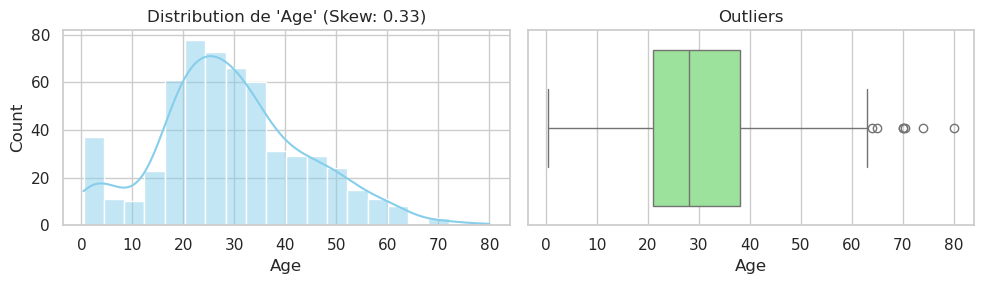

   📊 'Age' | Skew: 0.33 → Stratégie: MEAN.

🔹 'Cabin' | 77.7% manquants
   ❌ [DROP] 'Cabin' | 77.7% manquants → Trop de données manquantes pour être fiable.

🔹 'Embarked' | 0.3% manquants
   📊 'Embarked' | Catégorielle → Stratégie: MODE.

🔄 ENCODAGE : Transformation des variables catégorielles en numériques...
🔄 ALIGNEMENT : Synchronisation des colonnes entre X_train et X_test...
   ✅ Colonnes après alignement : 8 (identiques pour train/test).

📏 NORMALISATION : Standardisation des features (mean=0, std=1)...
✅ PIPELINE TERMINÉ :
   - X_train shape: (712, 8)
   - X_test shape: (179, 8)
   - Toutes les transformations ont été appliquées sans fuite de données.


In [28]:
# =========================================================
# 1. PARAMÈTRES GLOBAUX ET JUSTIFICATIONS
# =========================================================
TARGET_COLUMN = 'Survived'  # Colonne cible à prédire (classification binaire)
SEUIL_CARDINALITE = 0.50    # Seuil pour détecter les identifiants (ex: PassengerId, Name)
# Pourquoi 0.50 ? Une cardinalité > 50% signifie que plus de la moitié des valeurs sont uniques → identifiant.
SEUIL_SUPPRESSION = 40.0    # % maximal de valeurs manquantes avant suppression d'une colonne
# Pourquoi 40% ? Au-delà, la colonne est trop incomplète pour être fiable.
SEUIL_SKEWNESS = 1.0        # Seuil pour choisir entre mean/median (distribution symétrique vs. asymétrique)
# Pourquoi 1.0 ? Un skewness > 1 indique une asymétrie forte → la médiane est plus robuste.

# =========================================================
# 2. DÉTECTION DES COLONNES INUTILES (IDENTIFIANTS)
# =========================================================
def detecter_colonnes_inutiles(df: pd.DataFrame, target: str, seuil_card: float) -> pd.DataFrame:
    """
    Supprime les colonnes à haute cardinalité (ex: IDs, noms).
    Justification : Ces colonnes n'apportent aucune information prédictive et peuvent causer du surapprentissage.
    """
    cols_to_drop = []
    for col in df.columns:
        if col == target:
            continue  # On ignore la colonne cible
        cardinality = df[col].nunique() / len(df)
        if cardinality > seuil_card:
            cols_to_drop.append(col)
            print(f"❌ [DROP] '{col}' | Cardinalité: {cardinality:.2f} → Identifiant détecté (ex: PassengerId, Name).")
    return df.drop(columns=cols_to_drop)

df_clean = detecter_colonnes_inutiles(df.copy(), TARGET_COLUMN, SEUIL_CARDINALITE)
print(f"📌 Dataset nettoyé : {df_clean.shape[1]} colonnes restantes.\n")

# =========================================================
# 3. SPLIT TRAIN/TEST (ANTI-FUITE DE DONNÉES)
# =========================================================
X = df_clean.drop(columns=[TARGET_COLUMN])
y = df_clean[TARGET_COLUMN]

# Encodage de la cible si catégorielle (ex: 'Yes'/'No' → 1/0)
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)
    print(f"🔄 Encodage de '{TARGET_COLUMN}' : {np.unique(y)} (catégoriel → numérique).")

# Split en train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"📊 Split effectué : X_train={X_train.shape}, X_test={X_test.shape}.")
print("⚠️  Important : Toute transformation future sera 'fit' sur X_train uniquement pour éviter les fuites.\n")

# =========================================================
# 4. IMPUTATION CIBLÉE AVEC DIAGNOSTIC VISUEL
# =========================================================
def analyser_imputation(train: pd.DataFrame, test: pd.DataFrame, col: str, seuil_missing: float, seuil_skew: float) -> tuple:
    """
    Analyse une colonne, choisit une stratégie d'imputation, et affiche des visualisations.
    Retourne les DataFrames mis à jour et un booléen indiquant si la colonne a été conservée.
    """
    missing_pct = train[col].isnull().mean() * 100

    # Décision 1 : Suppression si trop de valeurs manquantes
    if missing_pct > seuil_missing:
        print(f"   ❌ [DROP] '{col}' | {missing_pct:.1f}% manquants → Trop de données manquantes pour être fiable.")
        return train.drop(columns=[col]), test.drop(columns=[col]), False

    # Décision 2 : Stratégie d'imputation
    if pd.api.types.is_numeric_dtype(train[col]):
        skew = train[col].skew()
        # Visualisation : Distribution + Outliers
        fig, ax = plt.subplots(1, 2, figsize=(10, 3))
        sns.histplot(train[col].dropna(), kde=True, ax=ax[0], color='skyblue')
        ax[0].set_title(f"Distribution de '{col}' (Skew: {skew:.2f})")
        sns.boxplot(x=train[col].dropna(), ax=ax[1], color='lightgreen')
        ax[1].set_title("Outliers")
        plt.tight_layout()
        plt.show()

        # Choix mean/median basé sur le skewness
        strat = 'median' if abs(skew) > seuil_skew else 'mean'
        print(f"   📊 '{col}' | Skew: {skew:.2f} → Stratégie: {strat.upper()}.")
    else:
        strat = 'most_frequent'
        print(f"   📊 '{col}' | Catégorielle → Stratégie: MODE.")

    # Application de l'imputation
    imp = SimpleImputer(strategy=strat)
    train[[col]] = imp.fit_transform(train[[col]])
    test[[col]] = imp.transform(test[[col]])
    return train, test, True

print("🔍 PHASE D'IMPUTATION : Analyse colonne par colonne...")
for col in X_train.columns:
    if X_train[col].isnull().sum() > 0:
        print(f"\n🔹 '{col}' | {X_train[col].isnull().mean()*100:.1f}% manquants")
        X_train, X_test, _ = analyser_imputation(X_train, X_test, col, SEUIL_SUPPRESSION, SEUIL_SKEWNESS)

# =========================================================
# 5. ENCODAGE DES VARIABLES CATÉGORIELLES
# =========================================================
print("\n🔄 ENCODAGE : Transformation des variables catégorielles en numériques...")
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Alignement des colonnes (pour éviter les différences entre train/test)
print("🔄 ALIGNEMENT : Synchronisation des colonnes entre X_train et X_test...")
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
print(f"   ✅ Colonnes après alignement : {X_train.shape[1]} (identiques pour train/test).")

# =========================================================
# 6. NORMALISATION (STANDARDSCALER)
# =========================================================
print("\n📏 NORMALISATION : Standardisation des features (mean=0, std=1)...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit uniquement sur le train !
X_test_scaled = scaler.transform(X_test)         # Transformation du test avec les mêmes paramètres

print(f"✅ PIPELINE TERMINÉ :")
print(f"   - X_train shape: {X_train_scaled.shape}")
print(f"   - X_test shape: {X_test_scaled.shape}")
print("   - Toutes les transformations ont été appliquées sans fuite de données.")

# KNN

---

## **1. Principe de l'Algorithme**
- **Fonctionnement** :
  - Pour prédire la classe d'un point, KNN cherche les `K` points les plus proches dans l'espace des features.
  - La classe majoritaire parmi ces `K` voisins est attribuée au point.
- **Hyperparamètres clés** :
  - `n_neighbors` (`K`) : Nombre de voisins à considérer.
  - `weights` : Poids des voisins (`uniform` ou `distance`).
  - `metric` : Métrique de distance (`euclidean`, `manhattan`, etc.).

---

## **2. Méthode du Coude pour Choisir `K`**
- **Processus** :
  1. Tester plusieurs valeurs de `K` (ex: `K = 1, 3, 5, ..., 31`).
  2. Calculer le **taux d'erreur** sur le jeu de test pour chaque `K`.
  3. Choisir le `K` où l'erreur est minimale (point d'inflexion de la courbe).
- **Pourquoi ?** :
  - Un `K` trop petit → **surapprentissage** (sensible au bruit).
  - Un `K` trop grand → **sous-apprentissage** (trop généraliste).

---

## **3. Hyperparamètres Utilisés**
   Hyperparamètre | Valeur          | Description                                                                 |
 |----------------|------------------|-----------------------------------------------------------------------------|
 | `n_neighbors`  | `1 à 31` (pas=2) | Plage de valeurs testées pour trouver le `K` optimal.                     |
 | `weights`      | `uniform`        | Tous les voisins ont le même poids (par défaut).                           |
 | `metric`       | `minkowski`      | Distance de Minkowski (équivalente à la distance euclidienne par défaut).  |
 | `p`            | `2`              | Paramètre de puissance pour la distance de Minkowski (`p=2` = euclidienne).|

 --- Démarrage du modèle : KNN
 --- Recherche du K optimal en utilisant la méthode du coude...


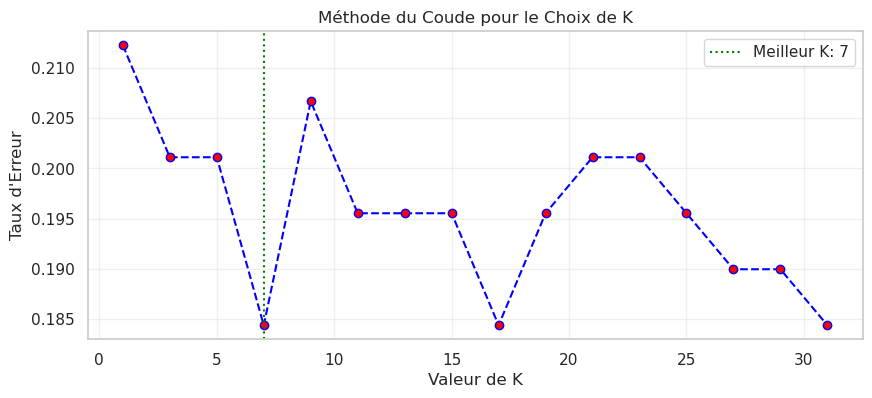

 --- K optimal sélectionné : 7 (taux d'erreur = 0.1844)


In [34]:
from matplotlib.colors import ListedColormap
print(" --- Démarrage du modèle : KNN")

# =========================================================
# 1. OPTIMISATION DU PARAMÈTRE K
# =========================================================
print

k_range = range(1, 32, 2)
erreurs = []

print(" --- Recherche du K optimal en utilisant la méthode du coude...")

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred_k = knn.predict(X_test_scaled)
    erreurs.append(np.mean(y_pred_k != y_test))

meilleur_k = k_range[np.argmin(erreurs)]

# Visualisation de la méthode du coude
plt.figure(figsize=(10, 4))
plt.plot(k_range, erreurs, marker='o', linestyle='--', color='blue', markerfacecolor='red')
plt.axvline(x=meilleur_k, color='green', linestyle=':', label=f'Meilleur K: {meilleur_k}')
plt.title('Méthode du Coude pour le Choix de K')
plt.xlabel('Valeur de K')
plt.ylabel('Taux d\'Erreur')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f" --- K optimal sélectionné : {meilleur_k} (taux d'erreur = {min(erreurs):.4f})")

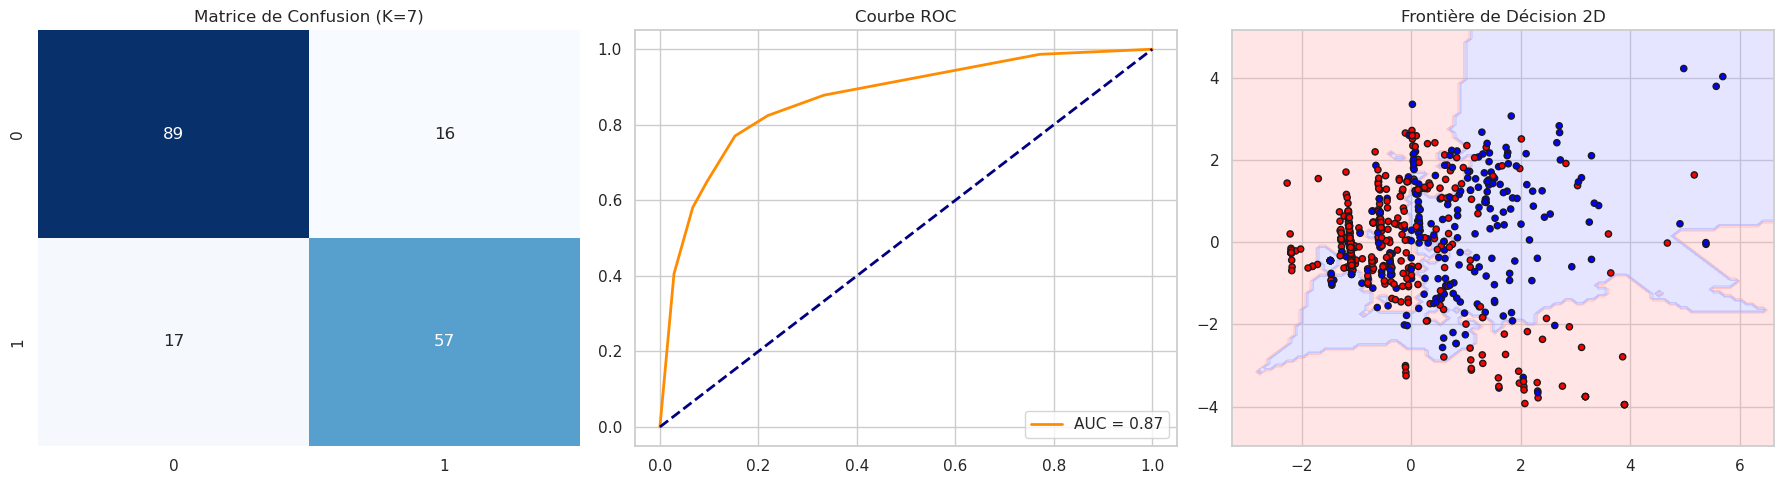

In [36]:
# =========================================================
# 2. ENTRAÎNEMENT ET ÉVALUATION
# =========================================================
knn_final = KNeighborsClassifier(n_neighbors=7) # <----- k à modifier
knn_final.fit(X_train_scaled, y_train)
y_final_pred = knn_final.predict(X_test_scaled)
y_prob = knn_final.predict_proba(X_test_scaled)[:, 1]

# =========================================================
# 3. ANALYSES VISUELLES
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A. Matrice de Confusion
cm = confusion_matrix(y_test, y_final_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title(f'Matrice de Confusion (K={meilleur_k})')

# B. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[1].set_title('Courbe ROC')
axes[1].legend(loc="lower right")

# C. Frontière de Décision (PCA 2D)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
knn_pca = KNeighborsClassifier(n_neighbors=meilleur_k).fit(X_train_pca, y_train)

x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
Z = knn_pca.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

axes[2].contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAAAFF']))
axes[2].scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap=ListedColormap(['#FF0000', '#0000FF']), s=20, edgecolor='k')
axes[2].set_title('Frontière de Décision 2D')

plt.tight_layout()
plt.show()

# Arbre de decision

---

## **1. Principe de l'Algorithme**

### **Fonctionnement**
- **Division récursive** :
  - L'arbre divise les données en sous-ensembles homogènes en posant des questions successives sur les features.
  - Chaque nœud représente une **condition** sur une feature (ex: `Age > 30`).
  - Chaque feuille représente une **classe** (pour la classification) ou une **valeur** (pour la régression).

- **Critère de division** :
  - **Gini Impurity** ou **Entropie** (pour la classification) :
    - Mesure l'impureté (désordre) des nœuds.
    - L'algorithme choisit la division qui **minimise l'impureté** des nœuds enfants.
  - **Variance** (pour la régression) :
    - Minimise la variance des valeurs dans les nœuds.

- **Avantages** :
  - **Interprétabilité** : Les règles de décision sont faciles à comprendre.
  - **Pas de prétraitement** : Pas besoin de normaliser les données.
  - **Gestion des features non linéaires** : Capture les relations complexes.

- **Inconvénients** :
  - **Surapprentissage** : Risque de créer un arbre trop complexe qui mémorise le bruit.
  - **Sensibilité aux petites variations** : Une légère modification des données peut changer la structure de l'arbre.

---

## **2. Hyperparamètres Clés**
   Hyperparamètre          | Description                                                                                     | Valeurs Typiques               | Impact                                                                                     |
 |-------------------------|-------------------------------------------------------------------------------------------------|--------------------------------|--------------------------------------------------------------------------------------------|
 | **`max_depth`**         | Profondeur maximale de l'arbre.                                                                | `None`, 3, 5, 10               | Limite la complexité. `None` = croissance jusqu'à ce que les feuilles soient pures.         |
 | **`min_samples_split`**| Nombre minimal d'échantillons requis pour diviser un nœud.                                    | 2, 5, 10                       | Évite les divisions sur des petits échantillons (réduit le surapprentissage).              |
 | **`min_samples_leaf`**  | Nombre minimal d'échantillons requis dans une feuille.                                        | 1, 2, 5                        | Contrôle la taille des feuilles.                                                           |
 | **`max_features`**      | Nombre de features à considérer pour la meilleure division.                                  | `None`, 'sqrt', 'log2'         | Réduit la variance et accélère l'entraînement. `None` = toutes les features.               |
 | **`criterion`**         | Fonction pour mesurer la qualité d'une division.                                              | 'gini', 'entropy'             | 'gini' est plus rapide, 'entropy' donne des arbres légèrement plus profonds.               |
 | **`splitter`**          | Stratégie pour choisir la division.                                                           | 'best', 'random'              | 'best' = choisit la meilleure division, 'random' = choisit aléatoirement (pour Random Forest). |
 | **`max_leaf_nodes`**    | Nombre maximal de feuilles.                                                                    | `None`, 10, 20                | Limite la croissance de l'arbre.                                                            |
 | **`min_impurity_decrease`** | Seuil minimal de réduction d'impureté pour diviser un nœud.                              | 0.0, 0.1                      | Évite les divisions qui n'améliorent pas suffisamment la pureté des nœuds.                 |
 | **`class_weight`**      | Poids associés aux classes pour gérer le déséquilibre.                                        | `None`, 'balanced'            | 'balanced' ajuste les poids inversement proportionnels aux fréquences des classes.         |
 | **`random_state`**      | Graine pour la reproductibilité.                                                               | 42, 123                       | Garantit les mêmes résultats à chaque exécution.                                           |


 --- Démarrage du modèle : Arbre de decision
 --- Recherche de la profondeur optimale avec validation croisée...


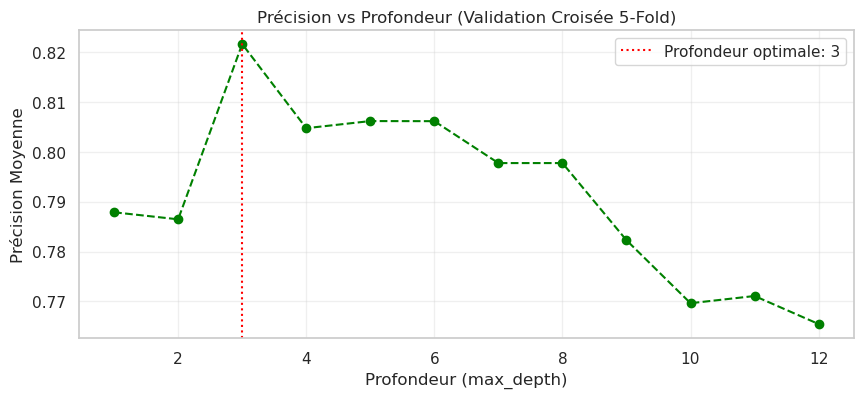

 --- Profondeur optimale : 3

 --- Recherche du min_samples_split optimal...
 --- min_samples_split optimal : 2

RAPPORT DE PERFORMANCE (ARBRE DÉFINITIF)
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       105
           1       0.80      0.69      0.74        74

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



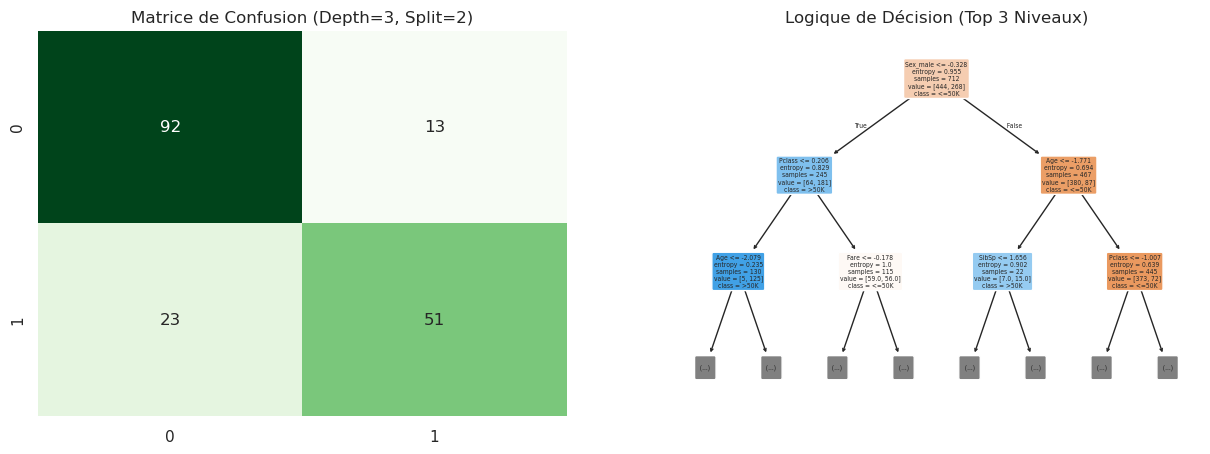

In [31]:
print(" --- Démarrage du modèle : Arbre de decision")

# =========================================================
# 1. RECHERCHE DE LA PROFONDEUR OPTIMALE (CROSS-VALIDATION)
# =========================================================
profondeurs = range(1, 13)
cv_scores = []

print(" --- Recherche de la profondeur optimale avec validation croisée...")

for d in profondeurs:
    tree_cv = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(tree_cv, X_train_scaled, y_train, cv=5)
    cv_scores.append(scores.mean())

best_depth_cv = profondeurs[np.argmax(cv_scores)]

# Visualisation de la précision en fonction de la profondeur
plt.figure(figsize=(10, 4))
plt.plot(profondeurs, cv_scores, marker='o', color='green', linestyle='--')
plt.axvline(x=best_depth_cv, color='red', linestyle=':', label=f'Profondeur optimale: {best_depth_cv}')
plt.title("Précision vs Profondeur (Validation Croisée 5-Fold)")
plt.xlabel("Profondeur (max_depth)")
plt.ylabel("Précision Moyenne")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f" --- Profondeur optimale : {best_depth_cv}")

# =========================================================
# 2. RECHERCHE DU SPLIT OPTIMAL (CROSS-VALIDATION)
# =========================================================
splits = [2, 5, 10, 15, 20, 30, 50]
split_scores = []

print("\n --- Recherche du min_samples_split optimal...")

for s in splits:
    tree_s = DecisionTreeClassifier(max_depth=best_depth_cv, min_samples_split=s, random_state=42)
    score = cross_val_score(tree_s, X_train_scaled, y_train, cv=5).mean()
    split_scores.append(score)

best_split_cv = splits[np.argmax(split_scores)]

print(f" --- min_samples_split optimal : {best_split_cv}")

# =========================================================
# 3. ENTRAÎNEMENT FINAL ET ÉVALUATION
# =========================================================
tree_final = DecisionTreeClassifier(
    max_depth=best_depth_cv,
    min_samples_split=best_split_cv,
    criterion='entropy',
    random_state=42
)
tree_final.fit(X_train_scaled, y_train)
y_pred_tree = tree_final.predict(X_test_scaled)

print("\n" + "="*60)
print("RAPPORT DE PERFORMANCE (ARBRE DÉFINITIF)")
print("="*60)
print(classification_report(y_test, y_pred_tree))

# Visualisations
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Matrice de Confusion
cm_tree = confusion_matrix(y_test, y_pred_tree)
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax[0])
ax[0].set_title(f"Matrice de Confusion (Depth={best_depth_cv}, Split={best_split_cv})")

# Visualisation de l'arbre (3 premiers niveaux)
plot_tree(
    tree_final, 
    max_depth=2, 
    feature_names=X_train.columns.tolist(),  # <----- change
    class_names=['<=50K', '>50K'],  # <----- change 
    filled=True, rounded=True, ax=ax[1])
ax[1].set_title("Logique de Décision (Top 3 Niveaux)")
plt.show()

# Bayes


---

## **1. Principe de l'Algorithme**

### **Fonctionnement**
- **Hypothèse de base** :
  - Les features sont **indépendantes conditionnellement** à la classe.
  - Chaque feature suit une **distribution normale (gaussienne)** pour chaque classe.
- **Calcul des probabilités** :
  - Pour chaque classe, le modèle calcule :
    - La **moyenne** et l'**écart-type** de chaque feature.
    - La **probabilité a priori** de la classe (fréquence dans le jeu d'entraînement).
  - La prédiction est basée sur le **théorème de Bayes** :
    \[
    P(y X) = \frac{P(X|y) \cdot P(y)}{P(X)}
    \]
    où \(P(y|X)\) est la probabilité de la classe \(y\) étant donné les features \(X\).

### **Avantages**
- **Rapidité** : Entraînement et prédiction très rapides.
- **Robustesse** : Performant même avec peu de données.
- **Pas d'hyperparamètres complexes** : Simple à utiliser.

### **Inconvénients**
- **Hypothèse d'indépendance** : Rarement vraie en pratique, mais souvent suffisante pour une bonne performance.
- **Sensibilité à la distribution des données** : Si les features ne suivent pas une distribution normale, les performances peuvent chuter.


 --- Démarrage du modèle : Gaussian Naive Bayes

RAPPORT DE PERFORMANCE (NAIVE BAYES)
              precision    recall  f1-score   support

  Non-Survie       0.81      0.80      0.80       105
      Survie       0.72      0.73      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



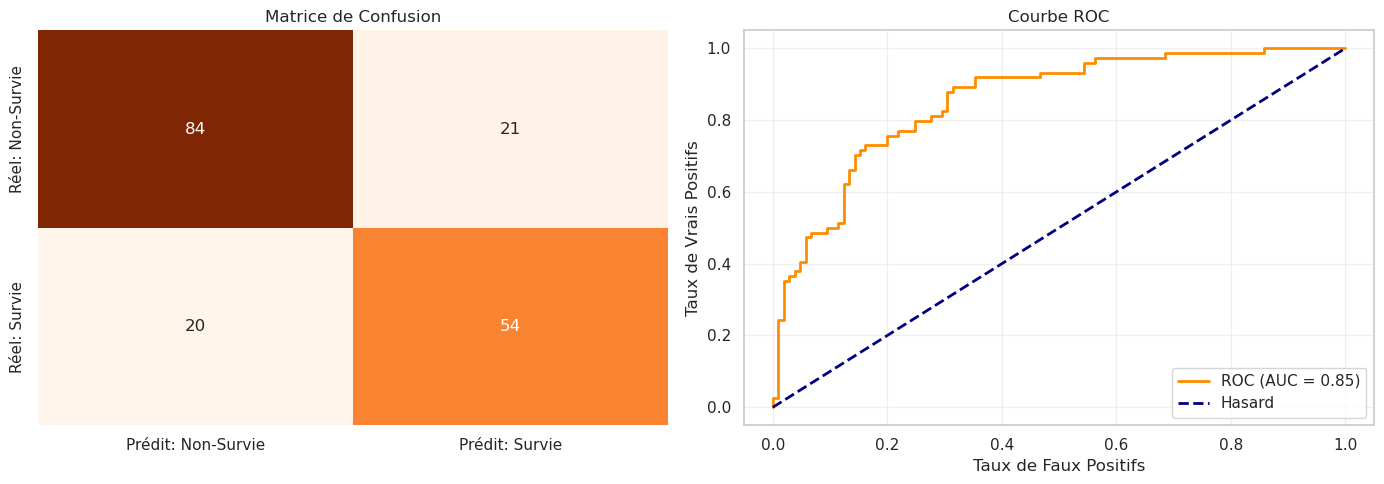

In [32]:
# =========================================================
# 1. ENTRAÎNEMENT DU MODÈLE GAUSSIAN NAIVE BAYES
# =========================================================
print(" --- Démarrage du modèle : Gaussian Naive Bayes")

# Initialisation et entraînement
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# Prédictions
y_pred_nb = nb_model.predict(X_test_scaled)
y_prob_nb = nb_model.predict_proba(X_test_scaled)[:, 1]  # Probabilités pour la classe positive

# =========================================================
# 2. ÉVALUATION TECHNIQUE
# =========================================================
print("\n" + "="*60)
print("RAPPORT DE PERFORMANCE (NAIVE BAYES)")
print("="*60)
print(classification_report(y_test, y_pred_nb, target_names=['Non-Survie', 'Survie']))

# =========================================================
# 3. DIAGNOSTIC GRAPHIQUE
# =========================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# A. Matrice de Confusion
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', cbar=False,
            xticklabels=['Prédit: Non-Survie', 'Prédit: Survie'],
            yticklabels=['Réel: Non-Survie', 'Réel: Survie'], ax=ax[0])
ax[0].set_title("Matrice de Confusion")

# B. Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_prob_nb)
roc_auc = auc(fpr, tpr)

ax[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard')
ax[1].set_title("Courbe ROC")
ax[1].set_xlabel("Taux de Faux Positifs")
ax[1].set_ylabel("Taux de Vrais Positifs")
ax[1].legend(loc="lower right")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# SVM

---

## **1. Principe de l'Algorithme SVM**

### **Objectif**
Trouver un **hyperplan** qui sépare au mieux les classes en maximisant la **marge** entre les points les plus proches de chaque classe (vecteurs de support).

### **Types de Noyaux**
   Noyau       | Description                                                                                     | Cas d'Usage                                                                 |
 |-------------|-------------------------------------------------------------------------------------------------|-----------------------------------------------------------------------------|
 | **Linéaire**| \( K(x, y) = x \cdot y \)                                                                       | Données linéairement séparables.                                            |
 | **RBF**     | \( K(x, y) = \exp(-\gamma \|x-y\|^2) \)                                                        | Données non linéairement séparables (noyau par défaut pour les problèmes complexes). |
 | **Polynomial** | \( K(x, y) = (\gamma x \cdot y + r)^d \)                                                   | Relations polynomiales entre les features.                                |
 | **Sigmoïde** | \( K(x, y) = \tanh(\gamma x \cdot y + r) \)                                                 | Cas spécifiques (peu utilisé).                                             |

### **Avantages**
- **Efficace en haute dimension** (même si le nombre de features est grand).
- **Robuste aux surapprentissements** (surtout avec une marge bien choisie).
- **Flexible** grâce aux différents noyaux.

### **Inconvénients**
- **Coût calculatoire** élevé pour les grands jeux de données.
- **Sensibilité au choix des hyperparamètres** (C, gamma, noyau).
- **Moins performant sur des données très bruitées**.

---

## **2. Hyperparamètres Clés**
 | Hyperparamètre | Description                                                                                     | Valeurs Typiques               | Impact                                                                                     |
 |----------------|-------------------------------------------------------------------------------------------------|--------------------------------|--------------------------------------------------------------------------------------------|
 | **`C`**        | Paramètre de régularisation. Contrôle le compromis entre marge large et erreur de classification. | 0.1, 1, 10, 100               | - Faible `C` : Marge large (plus de tolérance aux erreurs).                                |
 |                |                                                                                                 |                                | - Grand `C` : Marge étroite (moins de tolérance aux erreurs, risque de surapprentissage).  |
 | **`kernel`**   | Type de noyau pour transformer les données.                                                   | 'linear', 'rbf', 'poly'       | - 'linear' : Séparation linéaire.                                                          |
 |                |                                                                                                 |                                | - 'rbf' : Séparation non linéaire (noyau gaussien).                                         |
 | **`gamma`**    | Coefficient du noyau RBF, polynomial et sigmoïde. Détermine l'influence d'un échantillon.      | 'scale', 'auto', 0.1, 1, 10    | - Faible `gamma` : Influence large (courbe plus lisse).                                     |
 |                |                                                                                                 |                                | - Grand `gamma` : Influence locale (courbe plus complexe, risque de surapprentissage).      |
 | **`probability`** | Active la prédiction des probabilités.                                                      | True, False                   | Nécessaire pour les courbes ROC et les métriques probabilistes.                           |



 --- Démarrage du modèle : Support Vector Machine (SVM)
 --- Recherche des meilleurs hyperparamètres (5-Fold CV)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits

 --- Meilleure configuration : Noyau = rbf, C = 1, Gamma = scale
 --- Score moyen en Validation Croisée : 83.00%

RAPPORT DE PERFORMANCE FINAL (SVM)
              precision    recall  f1-score   support

  Non-Survie       0.81      0.90      0.86       105
      Survie       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



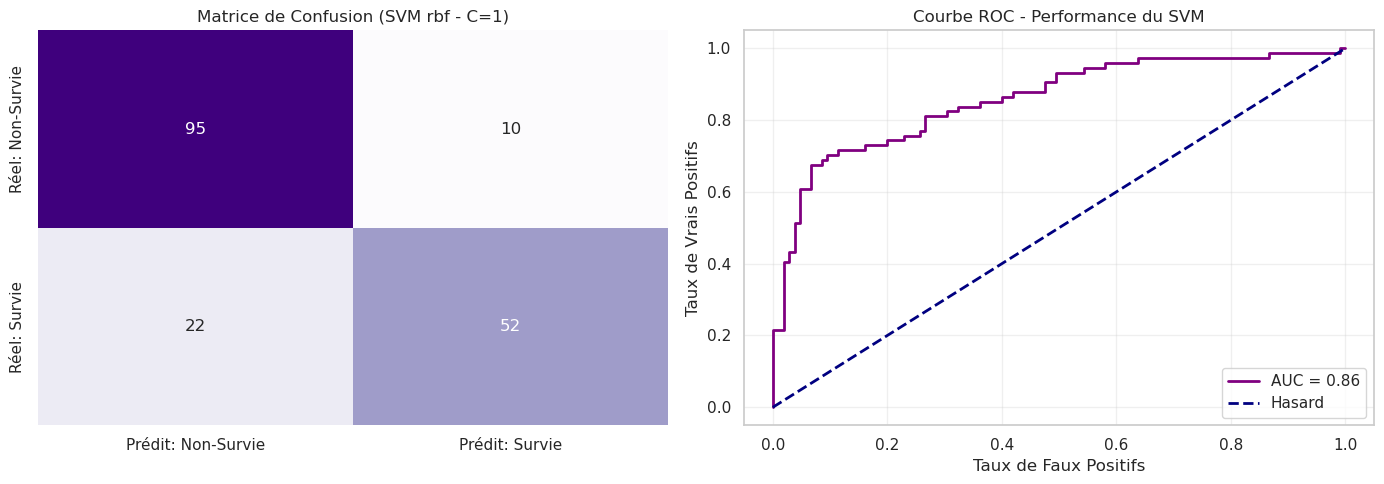

In [33]:
# =========================================================
# 1. OPTIMISATION DES HYPERPARAMÈTRES (GRID SEARCH + CV)
# =========================================================
print(" --- Démarrage du modèle : Support Vector Machine (SVM)")
print(" --- Recherche des meilleurs hyperparamètres (5-Fold CV)...")

# Grille de paramètres à explorer
param_grid = {
    'kernel': ['linear', 'rbf'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}

# Recherche par validation croisée
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

# Récupération du meilleur modèle et paramètres
svm_final = grid_search.best_estimator_
best_params = grid_search.best_params_

print(f"\n --- Meilleure configuration : Noyau = {best_params['kernel']}, C = {best_params['C']}, Gamma = {best_params['gamma']}")
print(f" --- Score moyen en Validation Croisée : {grid_search.best_score_:.2%}")

# =========================================================
# 2. ÉVALUATION SUR LE JEU DE TEST
# =========================================================
y_pred_svm = svm_final.predict(X_test_scaled)
y_prob_svm = svm_final.predict_proba(X_test_scaled)[:, 1]

print("\n" + "="*60)
print("RAPPORT DE PERFORMANCE FINAL (SVM)")
print("="*60)
print(classification_report(y_test, y_pred_svm, target_names=['Non-Survie', 'Survie']))

# =========================================================
# 3. VISUALISATIONS
# =========================================================
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# A. Matrice de Confusion
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', cbar=False,
            xticklabels=['Prédit: Non-Survie', 'Prédit: Survie'],
            yticklabels=['Réel: Non-Survie', 'Réel: Survie'], ax=ax[0])
ax[0].set_title(f"Matrice de Confusion (SVM {best_params['kernel']} - C={best_params['C']})")

# B. Courbe ROC
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)

ax[1].plot(fpr_svm, tpr_svm, color='purple', lw=2, label=f'AUC = {auc_svm:.2f}')
ax[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Hasard')
ax[1].set_title("Courbe ROC - Performance du SVM")
ax[1].set_xlabel("Taux de Faux Positifs")
ax[1].set_ylabel("Taux de Vrais Positifs")
ax[1].legend(loc="lower right")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparaison des modeles

## **1. Objectif**
Comparer les performances des 4 modèles testés sur le jeu de données Titanic :
- **KNN** (K-Nearest Neighbors)
- **Decision Tree** (Arbre de Décision)
- **Naive Bayes** (Bayésien Naïf)
- **SVM** (Support Vector Machine)

## **2. Métrique de Comparaison**
- **Accuracy (Précision)** : Proportion de prédictions correctes sur le jeu de test.
  - Formule : `(VP + VN) / Total`
  - Permet une comparaison directe entre les modèles.

## **3. Visualisation**
- **Barplot** : Représentation graphique des accuracies classées par ordre décroissant.
  - Le modèle **SVM** est mis en évidence comme "Champion".
  - Les valeurs d'accuracy sont affichées en pourcentage sur chaque barre.

## **4. Critères de Sélection du Vainqueur**
1. **Accuracy maximale** : Meilleure capacité à prédire correctement les classes.
2. **Stabilité** : Score élevé en validation croisée (pour SVM : `{grid_search.best_score_:.2%}`).
3. **Équilibre** : Meilleur compromis entre précision et recall (détection des vrais positifs).

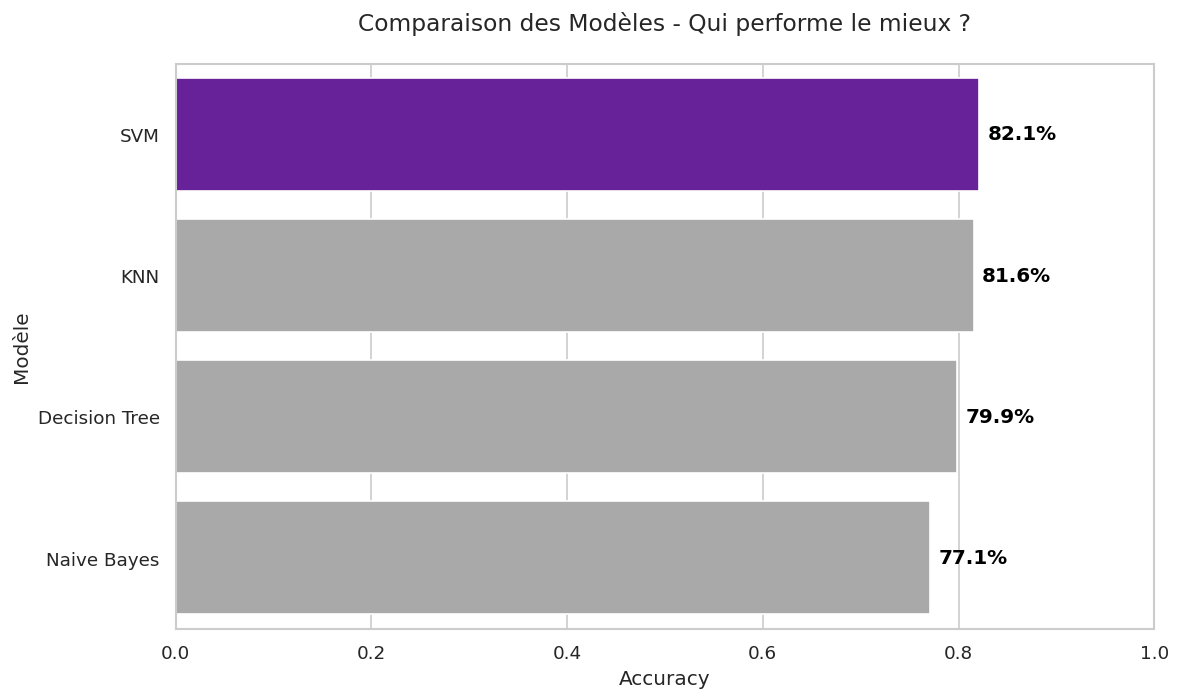


 --- RÉSULTATS FINAUX
 --- **Modèle vainqueur** : SVM (Accuracy = 82.12%)

 --- **Pourquoi SVM a gagné ?**
   - Hyperparamètres optimisés : {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
   - Score en validation croisée : 83.00%
   - Excellente capacité à trouver des frontières de décision non-linéaires

 --- **Paramètres optimaux du modèle vainqueur** :
   - C: 1
   - gamma: scale
   - kernel: rbf

 --- RAPPORT COMPLET DES PERFORMANCES
       Modèle  Accuracy                                      Params
          SVM  0.821229 {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}
          KNN  0.815642                                        None
Decision Tree  0.798883    {'max_depth': 3, 'min_samples_split': 2}
  Naive Bayes  0.770950                                        None


In [26]:
# =========================================================
# COMPARAISON GLOBALE DES MODÈLES (VERSION GÉNÉRALE)
# =========================================================

# 1. Préparation des données de comparaison
# (À adapter selon vos variables de prédiction existantes)
results = {
    'KNN': {'y_true': y_test, 'y_pred': y_final_pred, 'params': None},
    'Decision Tree': {'y_true': y_test, 'y_pred': y_pred_tree, 'params': {'max_depth': best_depth_cv, 'min_samples_split': best_split_cv}},
    'Naive Bayes': {'y_true': y_test, 'y_pred': y_pred_nb, 'params': None},
    'SVM': {'y_true': y_test, 'y_pred': y_pred_svm, 'params': best_params}
}

# 2. Calcul des métriques pour chaque modèle
model_metrics = []
for name, data in results.items():
    accuracy = accuracy_score(data['y_true'], data['y_pred'])
    model_metrics.append({
        'Modèle': name,
        'Accuracy': accuracy,
        'Params': data['params']
    })

# Conversion en DataFrame
df_results = pd.DataFrame(model_metrics)
df_results = df_results.sort_values(by='Accuracy', ascending=False)

# 3. Détermination du vainqueur
winner = df_results.iloc[0]
winner_name = winner['Modèle']
winner_score = winner['Accuracy']
winner_params = winner['Params']

# 4. Définition des couleurs (vainqueur en violet, autres en gris)
colors = ['#6a0dad' if model == winner_name else '#A9A9A9' for model in df_results['Modèle']]

# 5. Visualisation comparative
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Accuracy', y='Modèle', data=df_results, palette=colors)

# Ajout des pourcentages sur les barres
for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{width:.1%}',
                (width, p.get_y() + p.get_height() / 2),
                ha='left', va='center', fontsize=12, color='black',
                xytext=(5, 0), textcoords='offset points', fontweight='bold')

plt.title(f'Comparaison des Modèles - Qui performe le mieux ?', fontsize=14, pad=20)
plt.xlim(0, 1.0)
plt.xlabel('Accuracy')
plt.ylabel('Modèle')
plt.tight_layout()
plt.show()

# 6. Conclusion dynamique
print("\n" + "="*60)
print(" --- RÉSULTATS FINAUX")
print("="*60)

print(f" --- **Modèle vainqueur** : {winner_name} (Accuracy = {winner_score:.2%})")

# Message spécifique selon le modèle vainqueur
if winner_name == 'SVM':
    print("\n --- **Pourquoi SVM a gagné ?**")
    print(f"   - Hyperparamètres optimisés : {winner_params}")
    print(f"   - Score en validation croisée : {grid_search.best_score_:.2%}")
    print("   - Excellente capacité à trouver des frontières de décision non-linéaires")

elif winner_name == 'Decision Tree':
    print("\n --- **Pourquoi l'Arbre de Décision a gagné ?**")
    print(f"   - Profondeur optimale : {winner_params['max_depth']}")
    print(f"   - min_samples_split : {winner_params['min_samples_split']}")
    print("   - Bonne interprétabilité et gestion des non-linéarités")

elif winner_name == 'KNN':
    print("\n --- **Pourquoi KNN a gagné ?**")
    print("   - Simple et efficace pour des données localement similaires")
    print("   - Pas besoin d'entraînement complexe (lazy learning)")

elif winner_name == 'Naive Bayes':
    print("\n --- **Pourquoi Naive Bayes a gagné ?**")
    print("   - Très rapide et performant malgré sa simplicité")
    print("   - Robuste même avec peu de données")

# Affichage des paramètres si disponibles
if winner_params is not None:
    print(f"\n --- **Paramètres optimaux du modèle vainqueur** :")
    for param, value in winner_params.items():
        print(f"   - {param}: {value}")

print("\n" + "="*60)
print(" --- RAPPORT COMPLET DES PERFORMANCES")
print("="*60)
print(df_results.to_string(index=False))